In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
import warnings
warnings.filterwarnings('ignore')

**DATA EXPLORATION**



In [46]:
df=pd.read_csv('/content/drive/MyDrive/Project4 data/Processed_Flipdata - Processed_Flipdata.csv')

In [47]:
df.head()

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"


In [48]:
df.tail()

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
536,637,SAMSUNG Galaxy S23 5G,Cream,256,8,3900,50MP,12MP,0,15.49,Qualcomm Snapdragon 8 Gen 2,"79,999"
537,638,LAVA Z21,Cyan,32,2,3100,5MP,2MP,0,12.70,Octa Core,"5,998"
538,639,Tecno Spark 8T,Turquoise Cyan,64,4,5000,50MP,8MP,0,16.76,MediaTek Helio G35,"9,990"
539,641,SAMSUNG Galaxy A54 5G,Awesome Lime,128,8,5000,50MP,32MP,0,16.26,"Exynos 1380, Octa Core","38,999"
540,642,OPPO A77,Sky Blue,128,4,5000,50MP,8MP,0,16.66,Mediatek Helio G35,"15,999"


In [49]:
df.shape

(541, 12)

In [50]:
df.dtypes

,0
Unnamed: 0,int64
Model,object
Colour,object
Memory,int64
RAM,int64
Battery_,int64
Rear Camera,object
Front Camera,object
AI Lens,int64
Mobile Height,float64


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    object 
 2   Colour         541 non-null    object 
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    object 
 7   Front Camera   541 non-null    object 
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    object 
 11  Prize          541 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 50.8+ KB


In [52]:
df.describe()

,Unnamed: 0,Memory,RAM,Battery_,AI Lens,Mobile Height
count,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000
mean,289.711645,110.550832,5.397412,4871.587800,0.062847,16.431201
std,182.359185,60.600694,1.984923,780.148862,0.242911,2.523553
min,0.000000,16.000000,2.000000,800.000000,0.000000,4.500000
25%,135.000000,64.000000,4.000000,5000.000000,0.000000,16.510000
50%,273.000000,128.000000,6.000000,5000.000000,0.000000,16.710000
75%,434.000000,128.000000,8.000000,5000.000000,0.000000,16.940000
max,642.000000,256.000000,8.000000,7000.000000,1.000000,41.940000




*   **Supervised learning**



*   Dataset contains 541 rows and 12 features
*   Target Variable: Price


*   Mix of numerical and categorical features
*   No. of missing values checked





In [53]:
df.isnull().sum()

,0
Unnamed: 0,0
Model,0
Colour,0
Memory,0
RAM,0
Battery_,0
Rear Camera,0
Front Camera,0
AI Lens,0
Mobile Height,0


**DATA PREPROCESSING**


*   Remove unnecessary columns




In [54]:
df = df.drop('Unnamed: 0', axis=1)


*  Fix column names



In [55]:
df.rename(columns={'Prize': 'Price'},inplace=True)
df.rename(columns={'Battery_': 'Battery'},inplace=True)
df.rename(columns={'Processor_': 'Processor'},inplace=True)



*   Remove comma from price



In [56]:
df['Price'] = df['Price'].str.replace(',', '').astype(int)


*   Convert camera columns(e.g., '50MP' to 50)



In [57]:
df['Rear Camera']= df['Rear Camera'].str.replace('MP','').astype(int)
df['Front Camera']= df['Front Camera'].str.replace('MP','').astype(int)



*   Convert Numeric Columns Properly



In [58]:
df['Memory']= df['Memory'].astype(int)
df['RAM']= df['RAM'].astype(int)
df['Battery']= df['Battery'].astype(int)
df['Mobile Height']= df['Mobile Height'].astype(float)
df['AI Lens']= df['AI Lens'].astype(int)



*   Remove Outliers



In [59]:
Q1= df['Price'].quantile(0.25)
Q3= df['Price'].quantile(0.75)

IQR= Q3-Q1

df= df[(df['Price']>= Q1- 1.5*IQR)&
       (df['Price']<= Q3+ 1.5*IQR)]



* Encode Categorical values  



In [60]:
from sklearn.preprocessing import LabelEncoder

le= LabelEncoder()

df['Model']= le.fit_transform(df['Model'])
df['Colour']= le.fit_transform(df['Colour'])
df['Processor']=le.fit_transform(df['Processor'])

In [61]:
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 516 entries, 0 to 540
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Model          516 non-null    int64  
 1   Colour         516 non-null    int64  
 2   Memory         516 non-null    int64  
 3   RAM            516 non-null    int64  
 4   Battery        516 non-null    int64  
 5   Rear Camera    516 non-null    int64  
 6   Front Camera   516 non-null    int64  
 7   AI Lens        516 non-null    int64  
 8   Mobile Height  516 non-null    float64
 9   Processor      516 non-null    int64  
 10  Price          516 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 48.4 KB


,Model,Colour,Memory,RAM,Battery,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor,Price
0,18,152,64,4,6000,13,5,1,16.76,102,7299
1,18,19,64,4,6000,13,5,1,16.76,102,7299
2,30,142,128,8,5000,50,16,0,16.64,70,11999
3,62,192,32,2,5000,8,5,0,16.56,51,5649
4,7,124,128,8,5000,50,5,1,16.76,11,8999


**FEATURE EXTRACTION**


1. PRICE DISTRIBUTION



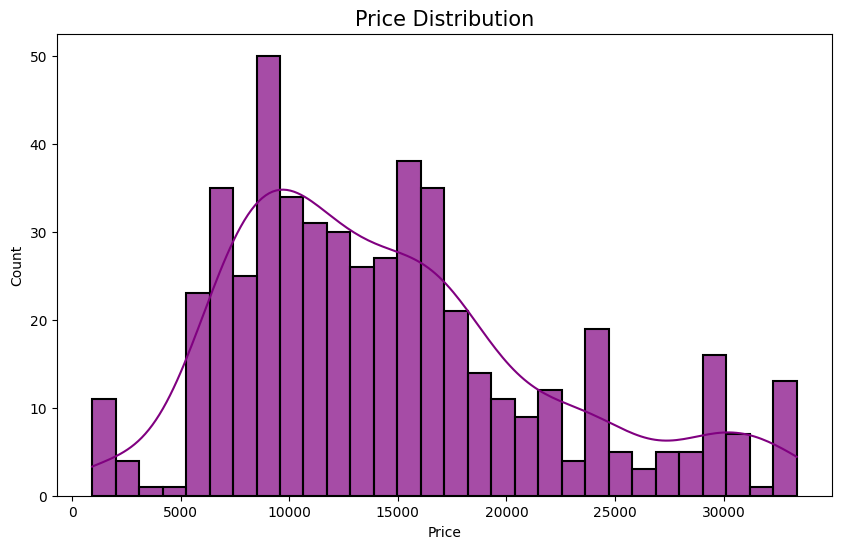

In [62]:
plt.figure(figsize=(10,6))
sns.histplot(df['Price'],kde=True,color='purple',edgecolor='black',alpha=0.7,linewidth=1.5,bins=30)

plt.title('Price Distribution',fontsize=15)
plt.show()


**Insight**


 Majority of mobile phones are concentrated in the lower to mid-price range, with fewer devices available at higher price points.

2. RAM vs Mobile Price

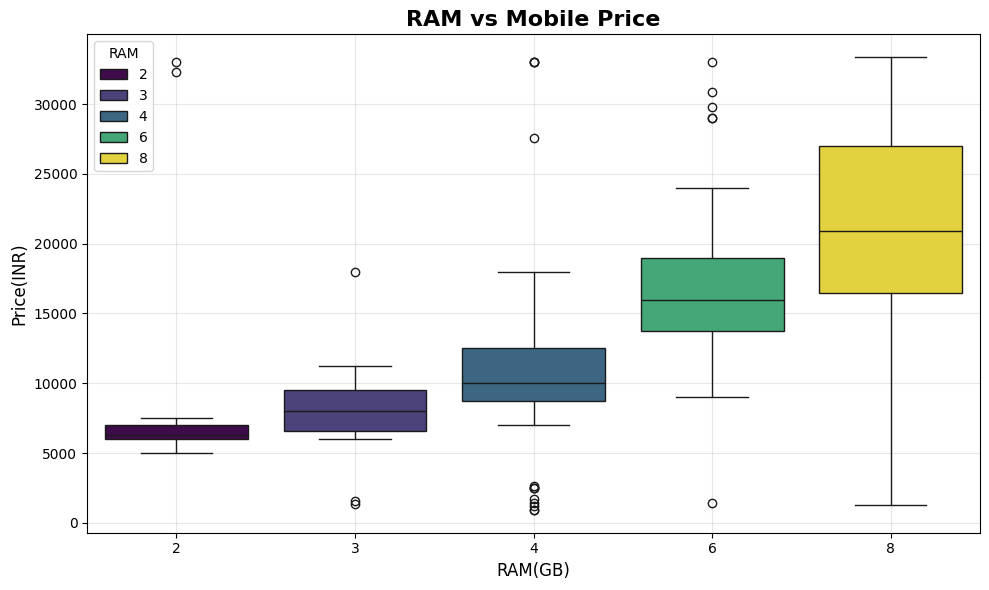

In [63]:
plt.figure(figsize=(10,6))

sns.boxplot(x='RAM',y='Price',data=df,hue='RAM',palette='viridis')

plt.title('RAM vs Mobile Price',fontsize=16,fontweight='bold')

plt.xlabel('RAM(GB)',fontsize=12)
plt.ylabel('Price(INR)',fontsize=12)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

**Insight**

 We can observe a clear positive correlation:

 as the RAM of a mobile phone increases, its price generally tends to increase as well.

 This is because higher RAM typically signifies better performance, allowing for smoother multitasking and more demanding applications, which are features often associated with premium and higher-priced devices.



3. MEMORY VS MOBILE PRICE

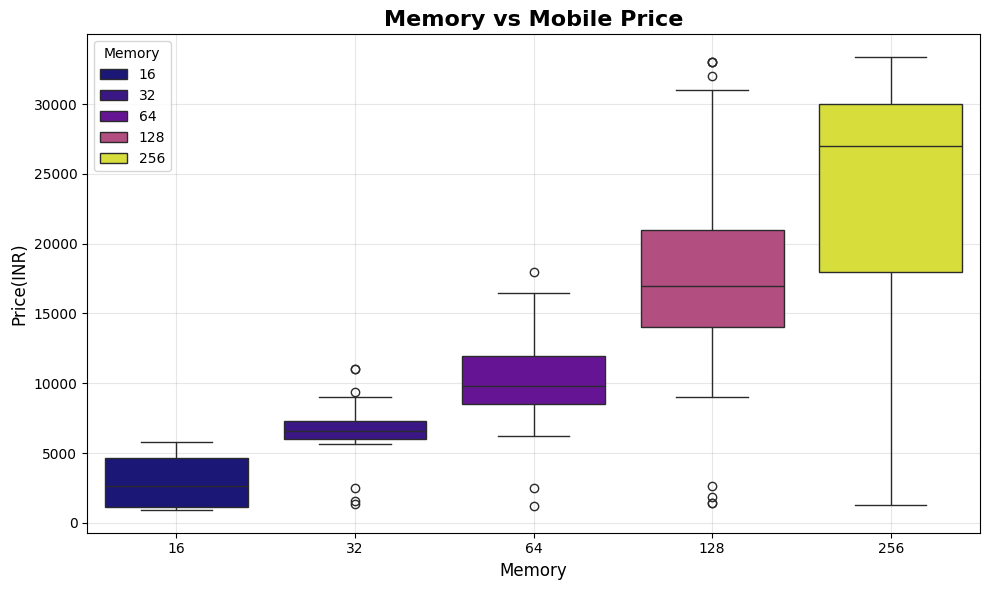

In [64]:
plt.figure(figsize=(10,6))

sns.boxplot(x='Memory',y='Price',data=df,hue='Memory',palette='plasma')

plt.title('Memory vs Mobile Price',fontsize=16,fontweight='bold')

plt.xlabel('Memory',fontsize=12)
plt.ylabel('Price(INR)',fontsize=12)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

**Insight**

we typically observe a similar trend to RAM.

Mobile phones with higher internal memory (storage) tend to be more expensive. This is because larger storage capacities are considered a premium feature, allowing users to store more apps, photos, videos, and other data, thus increasing the device's value and price point.

4. BATTERY VS MOBILE PRICS

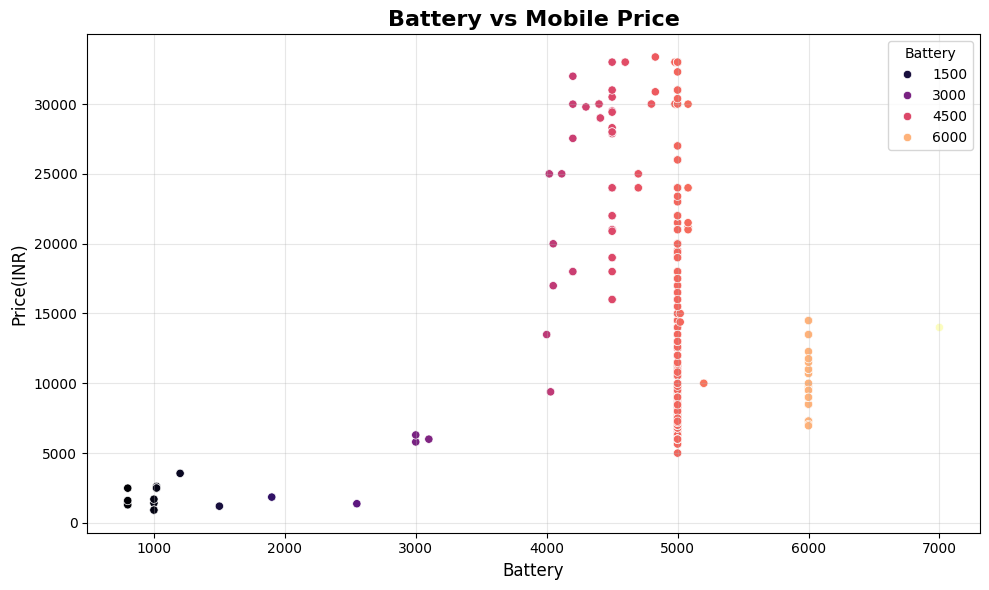

In [65]:
plt.figure(figsize=(10,6))

sns.scatterplot(x='Battery',y='Price',data=df,hue='Battery',palette='magma')

plt.title('Battery vs Mobile Price',fontsize=16,fontweight='bold')

plt.xlabel('Battery',fontsize=12)
plt.ylabel('Price(INR)',fontsize=12)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

**Insight**

Unlike RAM and Memory, the relationship between Battery capacity and Mobile Price might not always show a strictly linear positive correlation.

While a larger battery capacity generally adds value by offering longer usage times, it often acts more as a baseline feature or a differentiator within certain price segments rather than a primary driver of overall device cost.

Very large batteries can sometimes be found in budget-friendly phones, while high-end devices might optimize for battery efficiency and overall design rather than just raw capacity.

Therefore, the scatter plot is likely to show a more dispersed pattern, indicating that other factors heavily influence the price alongside battery size.

5. REAR CAMERA VS MOBILE PRICE

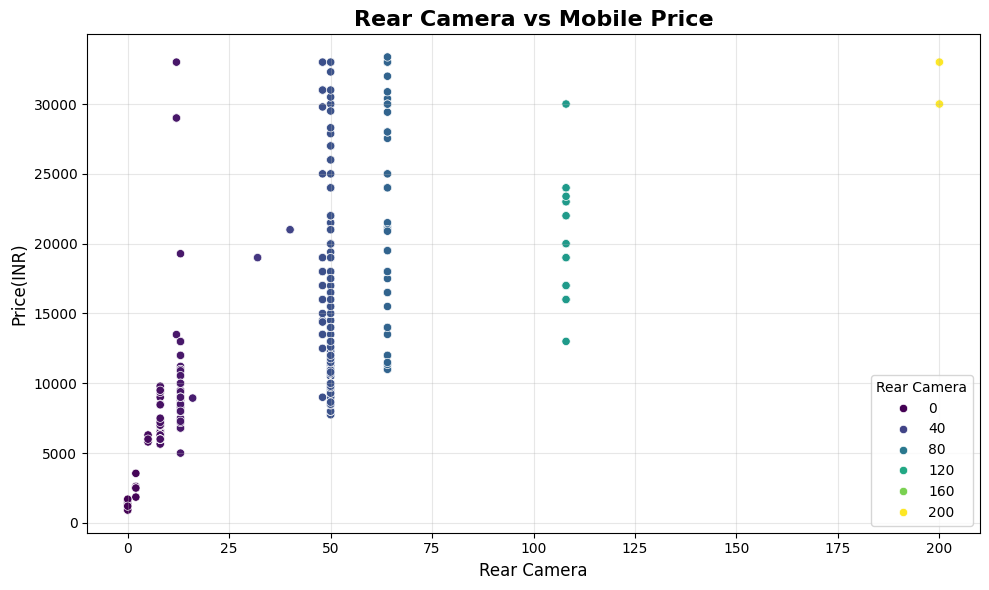

In [66]:
plt.figure(figsize=(10,6))

sns.scatterplot(x='Rear Camera',y='Price',data=df,hue='Rear Camera',palette='viridis')

plt.title('Rear Camera vs Mobile Price',fontsize=16,fontweight='bold')

plt.xlabel('Rear Camera',fontsize=12)
plt.ylabel('Price(INR)',fontsize=12)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

**Insight**

Generally, there is a positive correlation between the megapixel count of the rear camera and the mobile phone's price.

 Higher MP rear cameras are often associated with advanced imaging technologies, better sensor quality, and additional features (like optical image stabilization, multiple lenses, or advanced AI processing), which contribute to a higher overall cost and are typically found in more expensive, premium devices.

6. FRONT CAMERA VS MOBILE PRICE

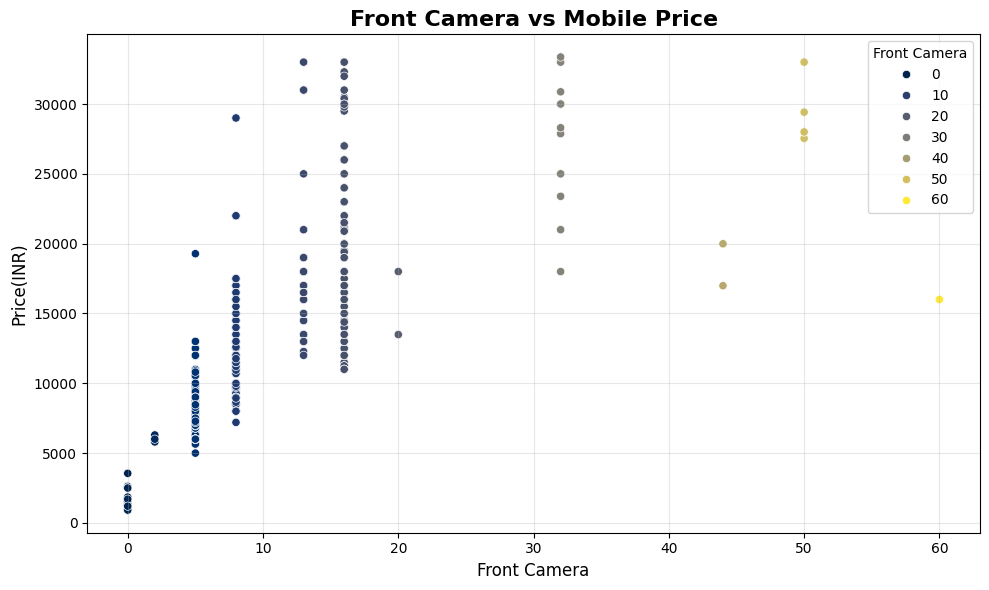

In [67]:
plt.figure(figsize=(10,6))

sns.scatterplot(x='Front Camera',y='Price',data=df,hue='Front Camera',palette='cividis')

plt.title('Front Camera vs Mobile Price',fontsize=16,fontweight='bold')

plt.xlabel('Front Camera',fontsize=12)
plt.ylabel('Price(INR)',fontsize=12)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

**Insight**

Similar to the rear camera, there is generally a positive correlation between the megapixel count of the front camera and the mobile phone's price.

 A higher MP front camera suggests a focus on better selfie and video call quality, which is a desirable feature often present in mid-range to high-end devices, thus commanding a higher price. While not as strong a driver as the main rear camera, it still contributes to the overall value proposition and price point.

7. AI LENS VS MOBILE PRICE

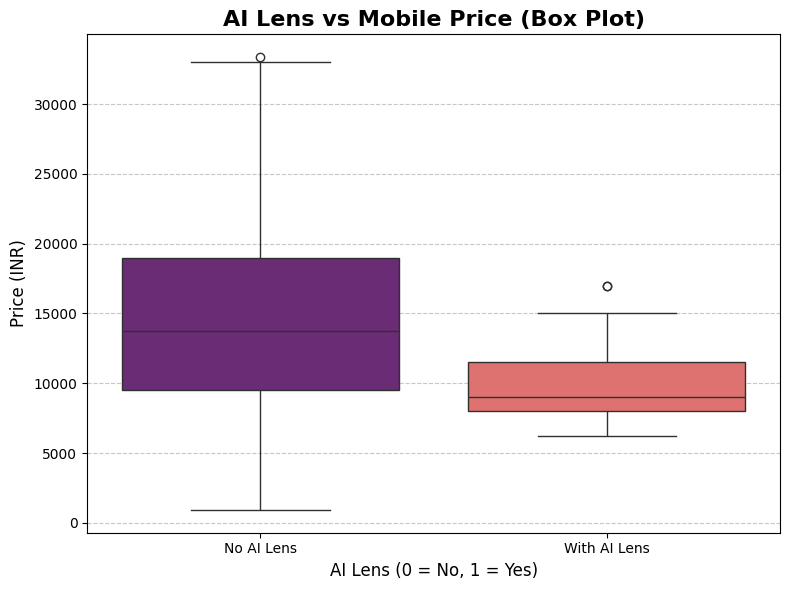

In [68]:
plt.figure(figsize=(8,6))
sns.boxplot(x='AI Lens', y='Price', data=df, hue='AI Lens', palette='magma', legend=False)
plt.title('AI Lens vs Mobile Price (Box Plot)', fontsize=16, fontweight='bold')
plt.xlabel('AI Lens (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Price (INR)', fontsize=12)
plt.xticks([0, 1], ['No AI Lens', 'With AI Lens'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Insight**

This plot effectively compares the price distributions for phones that have an AI Lens versus those that don't. You can observe the median price, the spread of prices (IQR), and potential outliers for both categories.

8. MOBILE HEIGHT VS MOBILE PRICE

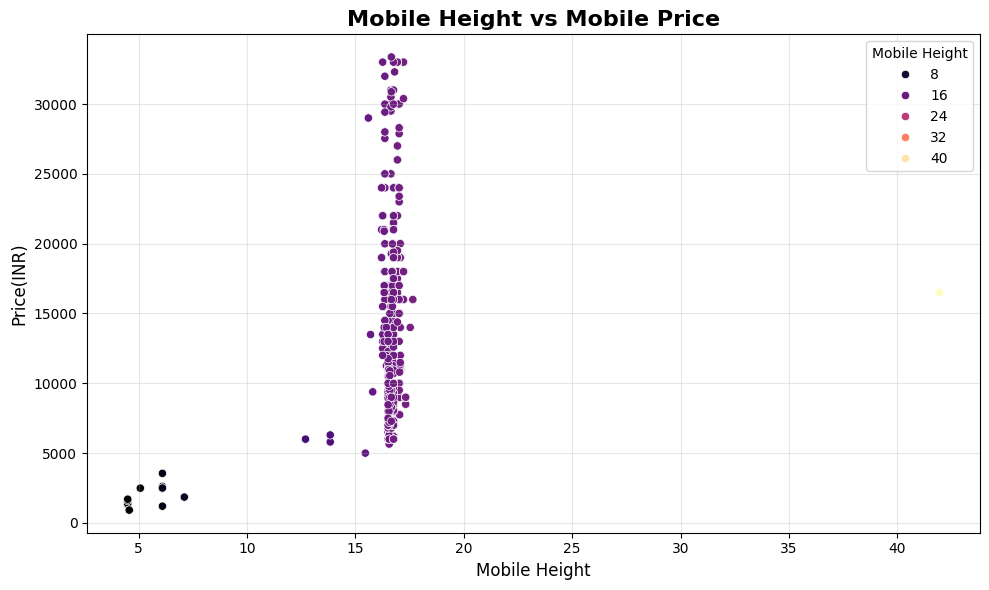

In [69]:
plt.figure(figsize=(10,6))

sns.scatterplot(x='Mobile Height',y='Price',data=df,hue='Mobile Height',palette='magma')

plt.title('Mobile Height vs Mobile Price',fontsize=16,fontweight='bold')

plt.xlabel('Mobile Height',fontsize=12)
plt.ylabel('Price(INR)',fontsize=12)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

**Insight**

From the 'Mobile Height vs Mobile Price' scatterplot, you'll likely observe that there isn't a strong, clear, and linear correlation. This means that mobile height alone is generally not a primary determinant of a phone's price.

9. PROCESSOR VS MOBILE PRICE

To make the 'Processor vs Mobile Price' plot more readable and less scattered, we'll group the less frequent processor types into an 'Other' category. This allows us to focus on the price distribution of the most common processors.

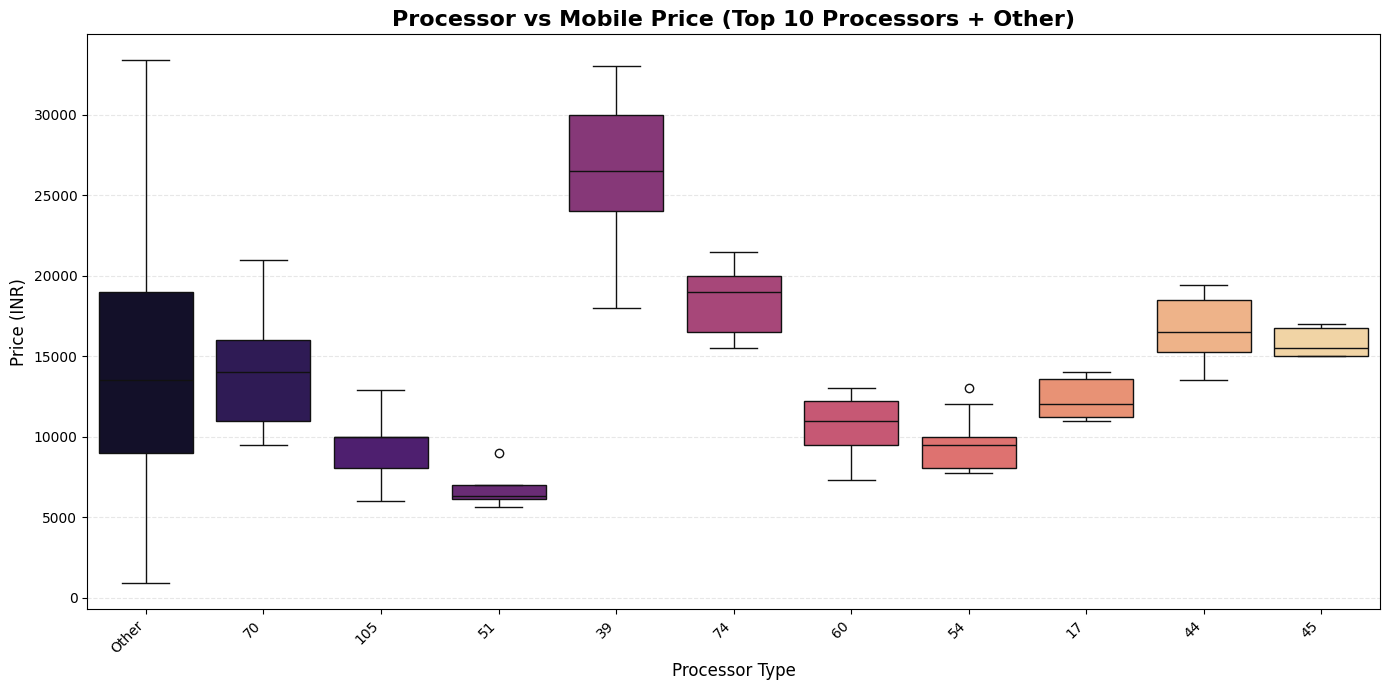

In [70]:
# Determine the value counts of each processor
processor_counts = df['Processor'].value_counts()

# Choose the number of top processors to display individually
top_n = 10

# Get the index of the top N most frequent processors
top_processors = processor_counts.nlargest(top_n).index

# Create a new column 'Processor_Grouped' for plotting
# Replace processors not in the top N with 'Other'
df_for_plotting = df.copy()
df_for_plotting['Processor_Grouped'] = df_for_plotting['Processor'].apply(
    lambda x: x if x in top_processors else 'Other'
)

# Generate the box plot with the grouped processors
plt.figure(figsize=(14, 7))
sns.boxplot(x='Processor_Grouped', y='Price', data=df_for_plotting, palette='magma',
            order=df_for_plotting['Processor_Grouped'].value_counts().index)
plt.title(f'Processor vs Mobile Price (Top {top_n} Processors + Other)', fontsize=16, fontweight='bold')
plt.xlabel('Processor Type', fontsize=12)
plt.ylabel('Price (INR)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**Insight**

Premium Processors: Processors associated with higher median prices and potentially wider price ranges (indicating they are used in both mid-range and high-end devices) are likely considered more powerful or premium.

Budget Processors: Conversely, processors with lower median prices and narrower price ranges often indicate their use in more budget-friendly devices.

'Other' Category: The 'Other' category provides a consolidated view of less common processors. Its price distribution can give an idea of the average pricing for these varied, less frequently seen chipsets.

This visualization effectively highlights which processors are driving higher prices in the mobile market and which are typically found in more affordable segments.



*   **Correlation Heatmap**



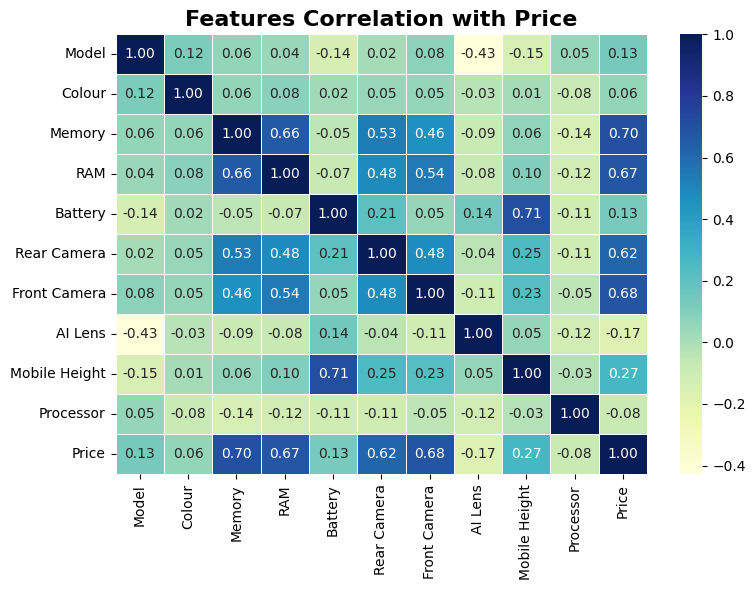

In [71]:
plt.figure(figsize=(8,6))

# Select only numerical columns for correlation calculation
numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(),annot=True,cmap='YlGnBu',linewidth=0.5,fmt='.2f')

plt.title('Features Correlation with Price',fontsize=16,fontweight='bold')

plt.tight_layout()

plt.show()

**Insight**

Front Camera: Shows a very strong influence on price, indicating that higher quality front cameras are a significant driver of cost.

Battery, Memory, and Processor: These features also exhibit a notable high influence on price, suggesting that better specifications in these areas contribute significantly to a device's value.

Model, Rear Camera, RAM, and Mobile Height: Have a moderate impact on price, meaning they contribute to the price but to a lesser extent than the top drivers.

Colour: Has a very low influence, indicating that the color of a phone generally does not significantly affect its price.

AI Lens: Shows negligible influence on price, suggesting its presence or absence has little bearing on the overall cost.

**MODEL BUILDING**

FEATURE AND TARGET SPLIT

In [72]:
x= df.drop('Price',axis=1)
y= df['Price']

Train Test Split

In [73]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)

Model- Random Forest(Best Model)

In [74]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Create copies to avoid modifying the original x_train/x_test dataframes
x_train_processed = x_train.copy()
x_test_processed = x_test.copy()

# Identify categorical columns that are still 'object' type in the training set
categorical_cols = x_train_processed.select_dtypes(include=['object']).columns

# Apply Label Encoding to each categorical column, ensuring integer type
for col in categorical_cols:
    le_temp = LabelEncoder() # Use a new encoder for each column
    x_train_processed[col] = le_temp.fit_transform(x_train_processed[col]).astype(int)

    # Create a mapping from the fitted encoder's classes
    label_to_int_map = {label: idx for idx, label in enumerate(le_temp.classes_)}

    # Define a function to apply the mapping, handling unseen labels in the test set
    # Assign unseen labels a new integer, which is one greater than the max seen in training
    def map_labels(label):
        return label_to_int_map.get(label, len(le_temp.classes_)) # Assign a new integer for unseen

    # Transform test data using the mapping function
    x_test_processed[col] = x_test_processed[col].apply(map_labels).astype(int)



**MODEL EVALUATION**

In [75]:
rf= RandomForestRegressor(n_estimators=100,random_state=42)

print(rf.fit(x_train_processed,y_train))

y_pred_rf= rf.predict(x_test_processed)

print('MAE:',mean_absolute_error(y_test,y_pred_rf))
print('RMSE:',np.sqrt(mean_squared_error(y_test,y_pred_rf)))
print('R2 Score:',r2_score(y_test,y_pred_rf))


RandomForestRegressor(random_state=42)
MAE: 1026.7744727564102
RMSE: 1877.7314478489463
R2 Score: 0.9257282055712617




*   Random Forest performs better than linear regression due to its ability to capture non-linear relationships.
*   Lower MAE and RMSE- better prediction accuracy



**FEATURE IMPORTANCE ANALYSIS**

In [76]:
importances= rf.feature_importances_
features=x.columns

feat_imp= pd.DataFrame({
    'Feature':features,
    'Importance':importances
}).sort_values(by='Importance',ascending=False)

feat_imp

,Feature,Importance
6,Front Camera,0.528906
4,Battery,0.091365
2,Memory,0.074750
9,Processor,0.073720
0,Model,0.058765
5,Rear Camera,0.057585
3,RAM,0.048513
8,Mobile Height,0.047590
1,Colour,0.018511
7,AI Lens,0.000294


**VISUALISATION**

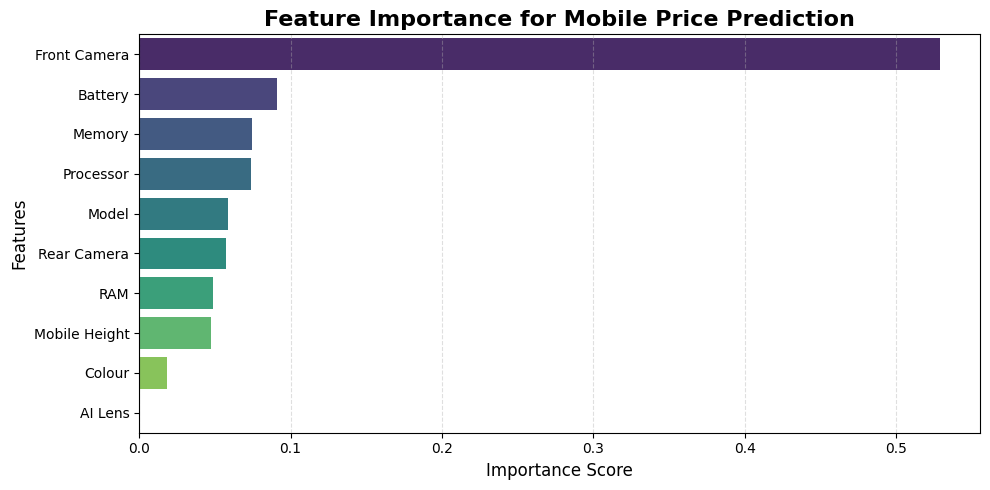

In [77]:
plt.figure(figsize=(10,5))

colors= sns.color_palette('viridis',len(feat_imp))

sns.barplot(x='Importance',y='Feature',data=feat_imp,palette=colors)

plt.title('Feature Importance for Mobile Price Prediction',fontsize=16,fontweight='bold')
plt.xlabel('Importance Score',fontsize=12)
plt.ylabel('Features',fontsize=12)

plt.grid(axis='x',linestyle='--',alpha=0.4)
plt.tight_layout()

plt.show()

**Front Camera** stands out as by far the most important feature, indicating that its specifications are a primary driver of mobile phone price.

**Battery, Memory, and Processor** follow as the next most significant factors, suggesting that better specifications in these areas notably increase a device's value.

**Model, Rear Camera, RAM, and Mobile Height** have a moderate level of importance, contributing to the price but to a lesser degree than the top features.

**Colour and AI Lens** show very low, almost negligible importance, implying that these attributes have minimal impact on the overall price prediction by the model.
